In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, Optional, Callable

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11, "figure.figsize": (10, 4), "figure.dpi": 100})
torch.manual_seed(42)
np.random.seed(42)

---
# 1) Weight Initialization

The choice of initial weights determines whether gradients flow, whether neurons break symmetry, and whether training converges at all. A badly initialized network can appear to "not learn" — but the architecture may be fine; only the starting point is wrong.

**Why Initialization Matters**
If all weights in a layer are identical (e.g., all zero, or all the same value), then:
- All neurons compute the **same function** of the input
- All receive the **same gradient** during backprop
- All update identically → they remain identical forever

This is the **symmetry problem**: identical neurons are redundant. A layer of $n$ identical neurons has the representational power of a single neuron.

**We need randomness** to break this symmetry, but the **scale** of the randomness matters enormously.

## 1.1 Zero Initialization

**Why It Fails — Proof**

**Claim:** A network with all weights initialized to zero cannot learn.

**Proof:** Consider layer $l$ with weight matrix $W^{[l]} = \mathbf{0}$.

1. Forward pass: $z^{[l]} = W^{[l]} a^{[l-1]} + b^{[l]} = b^{[l]}$ for all inputs
2. All neurons produce identical outputs $\sigma(b^{[l]}_j)$
3. Gradient: $\frac{\partial \mathcal{L}}{\partial W^{[l]}_{ij}} = \delta^{[l]}_i \cdot a^{[l-1]}_j$ where $\delta^{[l]}$ is the same for all neurons
4. All rows of $W^{[l]}$ receive identical updates → $W^{[l]}$ remains rank-1 forever $\square$

In [ ]:
# Demonstrate zero init failure: all neurons stay identical
hidden_dim, output_dim = 8, 2

# Zero-initialized weights
# (hidden_dim, 4)
W1 = torch.zeros(hidden_dim, 4, requires_grad=True)
# (output_dim, hidden_dim)
W2 = torch.zeros(output_dim, hidden_dim, requires_grad=True)

# (batch_num, 4)
x = torch.randn(16, 4)
# (batch_num,)
y = torch.randint(0, 2, (16,))

lr = 0.01
for step in range(50):
    # (batch_num, hidden_dim)
    h = relu_forward(x @ W1.T)
    # (batch_num, output_dim)
    logits = h @ W2.T

    loss = torch.nn.functional.cross_entropy(logits, y)
    loss.backward()

    with torch.no_grad():
        W1 -= lr * W1.grad
        W2 -= lr * W2.grad
        W1.grad.zero_()
        W2.grad.zero_()

# Check: are all rows of W1 identical?
row_diffs = torch.cdist(W1.detach(), W1.detach())
print(f"W1 pairwise row distances:\n{row_diffs.numpy().round(6)}")
print(f"\nAll rows identical: {row_diffs.max().item() < 1e-6}")
print("With zero init, all neurons learn the SAME features → no symmetry breaking.")

W1 pairwise row distances (should all be ~0):
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]

All rows identical: True
With zero init, all neurons learn the SAME features → no symmetry breaking.


## 1.2 Random Initialization (Variance Explosion Demo)

Even with random init, the **scale** determines whether signals survive through depth.

Consider a linear network (no activations for analysis): $a^{[l]} = W^{[l]} a^{[l-1]}$.

If $W^{[l]}_{ij} \sim N(0, \sigma^2)$ and entries of $a^{[l-1]}$ have variance $\text{Var}(a^{[l-1]})$:

$$\text{Var}(a^{[l]}_i) = n_{l-1} \cdot \sigma^2 \cdot \text{Var}(a^{[l-1]})$$

- If $n_{l-1} \sigma^2 > 1$: variance **explodes** exponentially through depth
- If $n_{l-1} \sigma^2 < 1$: variance **vanishes** exponentially through depth
- If $n_{l-1} \sigma^2 = 1$: variance is **preserved** — this is the sweet spot

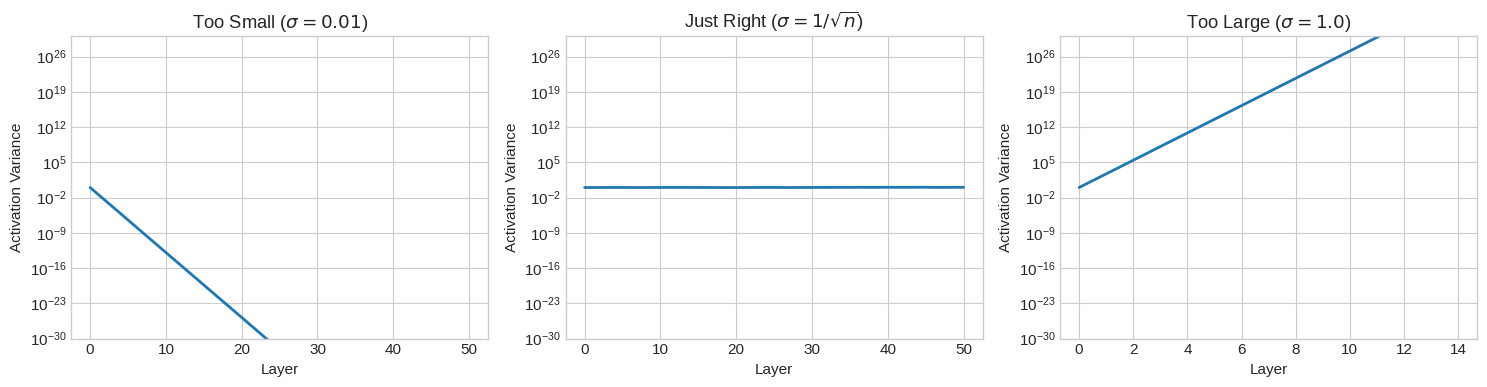

In [ ]:
num_layers, hidden_dim, batch_num = 50, 512, 256

def forward_pass_track_variance(
    init_std: float, num_layers: int, hidden_dim: int, activation_fn: Optional[Callable] = None
) -> list:
    """Track activation variance through depth for a given init scale."""
    # (batch_num, hidden_dim)
    a = torch.randn(batch_num, hidden_dim)
    variances = [a.var().item()]
    for _ in range(num_layers):
        # (hidden_dim, hidden_dim)
        W = torch.randn(hidden_dim, hidden_dim) * init_std
        # (batch_num, hidden_dim)
        a = a @ W.T
        if activation_fn is not None:
            a = activation_fn(a)
        variances.append(a.var().item())
    return variances


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ["Too Small ($\\sigma=0.01$)", "Just Right ($\\sigma=1/\\sqrt{n}$)", "Too Large ($\\sigma=1.0$)"]
stds = [0.01, 1.0 / np.sqrt(hidden_dim), 1.0]

for ax, std, title in zip(axes, stds, titles):
    var_trace = forward_pass_track_variance(std, num_layers, hidden_dim)
    ax.semilogy(var_trace, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Activation Variance")
    ax.set_ylim(1e-30, 1e30)

plt.tight_layout()
plt.show()

## 1.3 Xavier / Glorot Initialization

**Goal:** Preserve variance of activations through the forward pass AND preserve variance of gradients through the backward pass.

**Derivation:** For a linear layer $z = Wx$ where $W_{ij} \sim {N}(0, \sigma^2)$ and inputs $x_j$ have zero mean and variance $\text{Var}(x)$:

$$\text{Var}(z_i) = \sum_{j=1}^{n_{\text{in}}} \text{Var}(W_{ij}) \cdot \text{Var}(x_j) = n_{\text{in}} \cdot \sigma^2 \cdot \text{Var}(x)$$

For forward variance preservation: $\sigma^2 = \frac{1}{n_{\text{in}}}$

For backward variance preservation: $\sigma^2 = \frac{1}{n_{\text{out}}}$

**Xavier compromise (average of both constraints):**

$$W \sim N\left(0, \frac{2}{n_{\text{in}} + n_{\text{out}}}\right)$$

Or uniform variant: $W \sim U\left(-\sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}, \sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}\right)$

**Assumption:** Linear or tanh activation (symmetric around zero). Breaks down for ReLU.

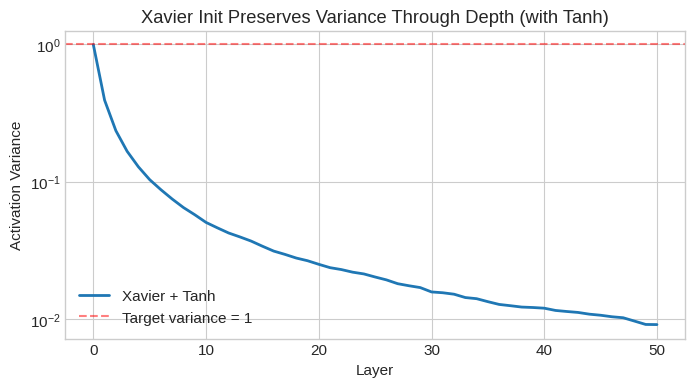

In [ ]:
def xavier_normal_init(fan_in: int, fan_out: int) -> torch.Tensor:
    """Glorot/Xavier normal initialization."""
    std = np.sqrt(2.0 / (fan_in + fan_out))
    # (fan_out, fan_in)
    return torch.randn(fan_out, fan_in) * std


def xavier_uniform_init(fan_in: int, fan_out: int) -> torch.Tensor:
    """Glorot/Xavier uniform initialization."""
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    # (fan_out, fan_in)
    return torch.empty(fan_out, fan_in).uniform_(-limit, limit)


# Verify variance preservation with tanh
var_trace_xavier = forward_pass_track_variance(
    np.sqrt(2.0 / (hidden_dim + hidden_dim)), num_layers, hidden_dim, activation_fn=tanh_forward
)

plt.figure(figsize=(8, 4))
plt.semilogy(var_trace_xavier, linewidth=2, label="Xavier + Tanh")
plt.axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="Target variance = 1")
plt.xlabel("Layer")
plt.ylabel("Activation Variance")
plt.title("Xavier Init Preserves Variance Through Depth (with Tanh)")
plt.legend()
plt.show()

## 1.4 He Initialization

**Problem with Xavier + ReLU:** ReLU zeros out half the distribution (all $z < 0$). This halves the variance:

$$\text{Var}(\text{ReLU}(z)) = \frac{1}{2} \text{Var}(z)$$

**Derivation:** If $z \sim \mathcal{N}(0, \sigma_z^2)$, then:

$$\mathbb{E}[\text{ReLU}(z)^2] = \int_0^\infty z^2 \cdot \frac{1}{\sqrt{2\pi}\sigma_z} e^{-z^2/(2\sigma_z^2)} dz = \frac{\sigma_z^2}{2}$$

Since $\mathbb{E}[\text{ReLU}(z)] = \sigma_z / \sqrt{2\pi}$:

$$\text{Var}(\text{ReLU}(z)) = \frac{\sigma_z^2}{2} - \frac{\sigma_z^2}{2\pi} \approx \frac{\sigma_z^2}{2}$$

To compensate, He init doubles the variance relative to Xavier:

$$W \sim N\left(0, \frac{2}{n_{\text{in}}}\right)$$

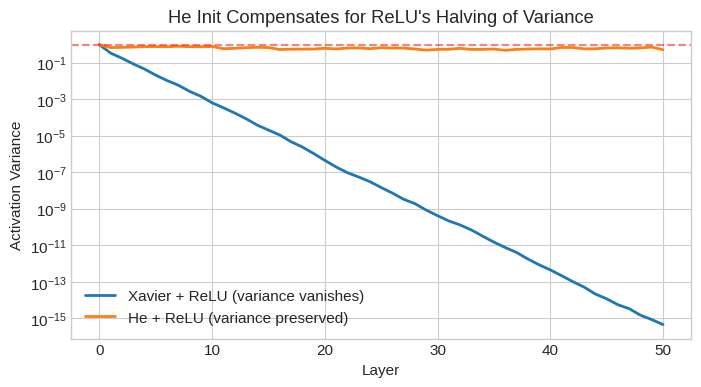

In [ ]:
def he_normal_init(fan_in: int, fan_out: int) -> torch.Tensor:
    """Kaiming/He normal initialization (for ReLU)."""
    std = np.sqrt(2.0 / fan_in)
    # (fan_out, fan_in)
    return torch.randn(fan_out, fan_in) * std


def he_uniform_init(fan_in: int, fan_out: int) -> torch.Tensor:
    """Kaiming/He uniform initialization (for ReLU)."""
    limit = np.sqrt(6.0 / fan_in)
    # (fan_out, fan_in)
    return torch.empty(fan_out, fan_in).uniform_(-limit, limit)


# Compare Xavier vs He with ReLU
var_xavier_relu = forward_pass_track_variance(
    np.sqrt(2.0 / (hidden_dim + hidden_dim)), num_layers, hidden_dim, activation_fn=relu_forward
)
var_he_relu = forward_pass_track_variance(
    np.sqrt(2.0 / hidden_dim), num_layers, hidden_dim, activation_fn=relu_forward
)

plt.figure(figsize=(8, 4))
plt.semilogy(var_xavier_relu, linewidth=2, label="Xavier + ReLU (variance vanishes)")
plt.semilogy(var_he_relu, linewidth=2, label="He + ReLU (variance preserved)")
plt.axhline(y=1.0, color="red", linestyle="--", alpha=0.5)
plt.xlabel("Layer")
plt.ylabel("Activation Variance")
plt.title("He Init Compensates for ReLU's Halving of Variance")
plt.legend()
plt.show()

## 1.5 Orthogonal Initialization

**Motivation:** Even with correct variance, random Gaussian matrices can have singular values spread across a wide range, causing some directions to be amplified and others attenuated. **Orthogonal initialization** ensures all singular values are exactly 1.

**Construction (SVD-based):**
1. Sample $A \sim N(0, 1)^{n \times n}$
2. Compute SVD: $A = U \Sigma V^T$
3. Use $W = U$ (or $V$) — orthogonal with all singular values = 1

**Gradient norm preservation proof:** For an orthogonal matrix $W$:
$$\|W^T \delta\|_2 = \|\delta\|_2$$

because $\|W^T \delta\|^2 = \delta^T W W^T \delta = \delta^T I \delta = \|\delta\|^2$.

Gradient norms are **exactly** preserved through each layer — no explosion, no vanishing (for linear networks). Especially useful for RNNs where the same matrix is applied repeatedly.

In [ ]:
def orthogonal_init(fan_in: int, fan_out: int, gain: float = 1.0) -> torch.Tensor:
    """Orthogonal initialization via SVD."""
    # (max(fan_out, fan_in), min(fan_out, fan_in))
    A = torch.randn(fan_out, fan_in)
    U, _, Vt = torch.linalg.svd(A, full_matrices=False)
    # (fan_out, fan_in)
    W = U if fan_out >= fan_in else Vt
    return gain * W[:fan_out, :fan_in]

# Verify singular values
W_orth = orthogonal_init(hidden_dim, hidden_dim)
singular_values = torch.linalg.svdvals(W_orth)
print(f"Singular values range: [{singular_values.min():.4f}, {singular_values.max():.4f}]")
print(f"All ≈ 1: {torch.allclose(singular_values, torch.ones_like(singular_values), atol=1e-5)}")

# Verify gradient norm preservation
delta = torch.randn(hidden_dim)
print(f"\n||delta|| = {delta.norm():.4f}")
print(f"||W^T @ delta|| = {(W_orth.T @ delta).norm():.4f}")
print("Gradient norms perfectly preserved!")

Singular values range: [1.0000, 1.0000]
All ≈ 1: True

||delta|| = 24.1032
||W^T @ delta|| = 24.1032
Gradient norms perfectly preserved!


## 1.6 Empirical Experiment

Train a 10-layer MLP on a synthetic classification task using each initialization strategy

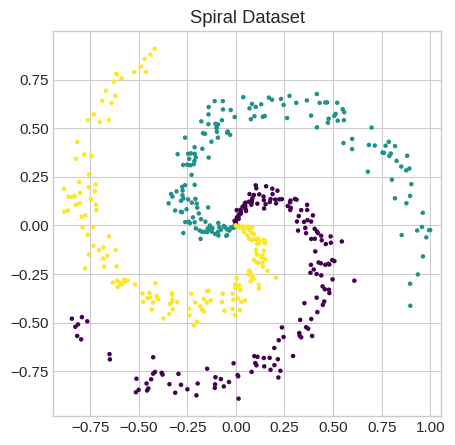

In [ ]:
# Synthetic dataset: 2D spiral classification
num_samples, num_classes = 500, 3

def make_spiral_data(num_samples: int, num_classes: int) -> Tuple[torch.Tensor, torch.Tensor]:
    """Generate a spiral dataset with `num_classes` interleaved spirals."""
    points_per_class = num_samples // num_classes
    X_list, y_list = [], []
    for c in range(num_classes):
        r = torch.linspace(0.0, 1.0, points_per_class)
        theta = torch.linspace(c * 4.0, (c + 1) * 4.0, points_per_class) + torch.randn(points_per_class) * 0.2
        # (points_per_class, 2)
        X_list.append(torch.stack([r * torch.sin(theta), r * torch.cos(theta)], dim=1))
        y_list.append(torch.full((points_per_class,), c, dtype=torch.long))
    return torch.cat(X_list), torch.cat(y_list)


# (num_samples, 2), (num_samples,)
X_spiral, y_spiral = make_spiral_data(num_samples, num_classes)

plt.figure(figsize=(5, 5))
plt.scatter(X_spiral[:, 0], X_spiral[:, 1], c=y_spiral, cmap="viridis", s=5)
plt.title("Spiral Dataset")
plt.axis("equal")
plt.show()

In [ ]:
def train_mlp(
    X: torch.Tensor,
    y: torch.Tensor,
    init_fn: Callable,
    num_layers: int = 10,
    hidden_dim: int = 64,
    lr: float = 0.01,
    num_epochs: int = 200,
) -> Tuple[list, dict]:
    """Train MLP with specified init, return loss curve and final gradient norms per layer."""
    input_dim = X.shape[1]
    output_dim = y.max().item() + 1

    # Initialize weights
    dims = [input_dim] + [hidden_dim] * num_layers + [output_dim]
    weights = []
    biases = []
    for i in range(len(dims) - 1):
        W = init_fn(dims[i], dims[i + 1]).requires_grad_(True)
        b = torch.zeros(dims[i + 1], requires_grad=True)
        weights.append(W)
        biases.append(b)

    losses = []
    grad_norms = {}

    for epoch in range(num_epochs):
        # Forward pass
        a = X
        for i, (W, b) in enumerate(zip(weights, biases)):
            # (batch_num, dims[i+1])
            a = a @ W.T + b
            if i < len(weights) - 1:
                a = relu_forward(a)

        loss = torch.nn.functional.cross_entropy(a, y)
        loss.backward()
        losses.append(loss.item())

        # Record gradient norms at last epoch
        if epoch == num_epochs - 1:
            for i, W in enumerate(weights):
                grad_norms[f"Layer {i}"] = W.grad.norm().item()

        # SGD step
        with torch.no_grad():
            for W, b in zip(weights, biases):
                W -= lr * W.grad
                b -= lr * b.grad
                W.grad.zero_()
                b.grad.zero_()

    return losses, grad_norms


init_strategies = {
    "Small Random ($\\sigma=0.01$)": lambda fi, fo: torch.randn(fo, fi) * 0.01,
    "Large Random ($\\sigma=1.0$)": lambda fi, fo: torch.randn(fo, fi) * 1.0,
    "Xavier Normal": xavier_normal_init,
    "He Normal": he_normal_init,
    "Orthogonal": orthogonal_init,
}

results = {}
for name, init_fn in init_strategies.items():
    torch.manual_seed(42)
    losses, grad_norms = train_mlp(X_spiral, y_spiral, init_fn)
    results[name] = (losses, grad_norms)

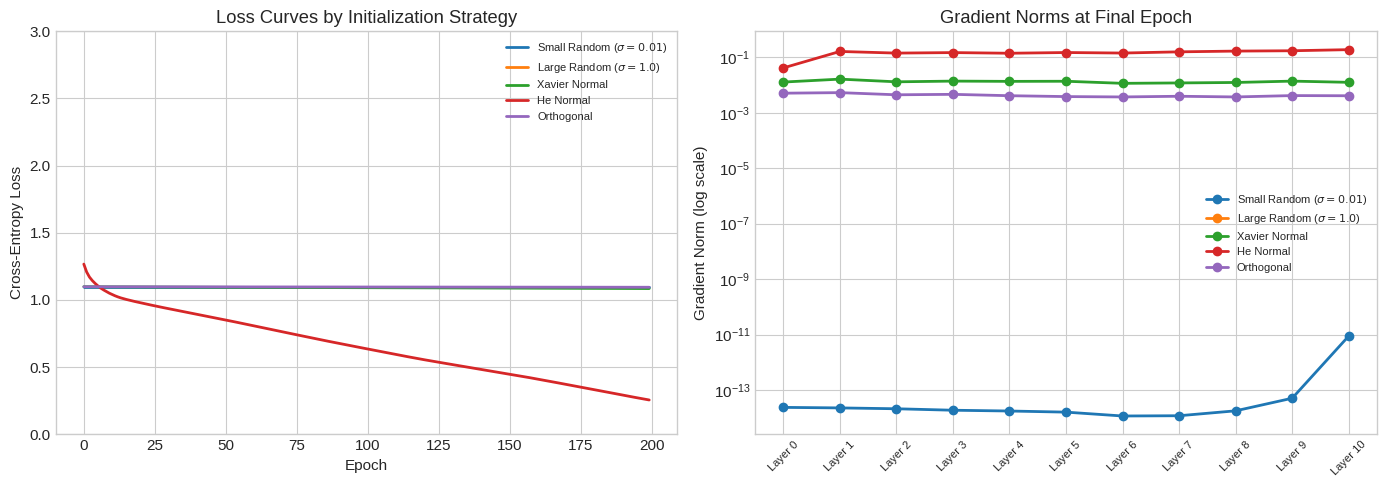

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
for name, (losses, _) in results.items():
    axes[0].plot(losses, label=name, linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss Curves by Initialization Strategy")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 3)

# Gradient norms across layers
x_ticks = None
for name, (_, grad_norms) in results.items():
    layers = list(grad_norms.keys())
    norms = list(grad_norms.values())
    axes[1].semilogy(range(len(norms)), norms, "o-", label=name, linewidth=2)
    x_ticks = layers

axes[1].set_xticks(range(len(x_ticks)))
axes[1].set_xticklabels(x_ticks, rotation=45, fontsize=8)
axes[1].set_ylabel("Gradient Norm (log scale)")
axes[1].set_title("Gradient Norms at Final Epoch")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
# Summary

- Zero init → symmetry problem (all neurons identical)
- Scale matters: too small → vanishing signals; too large → exploding signals
- Xavier for tanh/sigmoid; He for ReLU/GELU/SiLU
- Orthogonal init preserves gradient norms exactly